# Assignee Predictor V7 - Robust Validation & Tuning


In [80]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, top_k_accuracy_score
from sklearn.utils import resample
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

# Models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

warnings.filterwarnings('ignore')


In [81]:
# -----------------------------
# 1️⃣ ROBUST DATA LOADING
# -----------------------------
PROJECTS = {
    'Aurora': {
        'issues':  r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Aurora Project\Aurora Issues 554.csv',
        'summary': r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Aurora Project\Aurora Issues summery 568.csv',
    }
}

ASSIGNEE_MAP = {
    'maximk': 'Maxim Khutornenko', 'wfarner': 'Bill Farner',
    'kevints': 'Kevin Sweeney', 'mchucarroll': 'Mark Chu-Carroll',
    'zmanji': 'Zameer Manji', 'joshua.cohen': 'Joshua Cohen',
    'wickman': 'Brian Wickman', 'davmclau': 'David McLaughlin'
}
ALLOWED_ASSIGNEES = list(ASSIGNEE_MAP.keys())

def _lower_cols(df):
    df.columns = [c.strip().replace(' ', '_').lower() for c in df.columns]
    return df

def load_data():
    combined = []
    for pname, p in PROJECTS.items():
        try:
            iss = _lower_cols(pd.read_csv(p['issues'], on_bad_lines='skip', engine='python'))
            summ = _lower_cols(pd.read_csv(p['summary'], on_bad_lines='skip', engine='python'))
            iss.rename(columns={'priority': 'priorityid', 'storypoints': 'storypoint'}, inplace=True)
            
            if 'key' in iss.columns: iss['key'] = iss['key'].str.upper().str.strip()
            if 'issuekey' in summ.columns: summ['issuekey'] = summ['issuekey'].str.upper().str.strip()
            
            merged = iss.merge(summ, left_on='key', right_on='issuekey', how='inner', suffixes=('', '_y'))
            
            if 'assignee_y' in merged.columns: merged['assignee'] = merged['assignee_y'].fillna(merged.get('assignee', np.nan))
            if 'summary_y' in merged.columns: merged['summary'] = merged['summary_y'].fillna(merged.get('summary', ''))
            
            merged['text_content'] = merged['summary'].fillna('') + ' ' + merged.get('description', '').fillna('')
            merged['project'] = pname
            combined.append(merged)
        except Exception:
            continue
    return pd.concat(combined, ignore_index=True) if combined else pd.DataFrame()

df = load_data()
if 'assignee' in df.columns:
    df = df[df['assignee'].isin(ALLOWED_ASSIGNEES)]
    df['assignee_full'] = df['assignee'].map(ASSIGNEE_MAP)

print(f'Data Loaded: {df.shape}')


Data Loaded: (824, 35)


In [82]:
# -----------------------------
# 2️⃣ ROBUST CROSS-VALIDATION
# -----------------------------
X = df[['storypoint', 'priorityid', 'issuetype', 'project', 'text_content', 'status']]
y = df['assignee']

le = LabelEncoder()
y_enc = le.fit_transform(y)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Dummy (Baseline)': DummyClassifier(strategy='stratified'),
    'Random Forest (NLP)': RandomForestClassifier(n_estimators=300, max_depth=20, n_jobs=-1, random_state=42),
    'XGBoost (NLP)': XGBClassifier(n_estimators=500, max_depth=10, learning_rate=0.05, n_jobs=-1, random_state=42),
    'SVM (NLP)': SVC(kernel='linear', probability=True)
}

results = {name: [] for name in models}

print('Starting 5-Fold Stratified Cross-Validation (with Safe Oversampling)...\n')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_enc), 1):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y_enc[train_idx], y_enc[val_idx]
    
    # --- OVERSAMPLE TRAIN FOLD ONLY ---
    train_data = X_train_fold.copy()
    train_data['target'] = y_train_fold
    max_count = train_data['target'].value_counts().max()
    
    balanced_chunks = []
    for cls, group in train_data.groupby('target'):
        balanced_chunks.append(resample(group, replace=True, n_samples=max_count, random_state=42))
    
    train_bal = pd.concat(balanced_chunks)
    X_train_bal = train_bal.drop('target', axis=1)
    y_train_bal = train_bal['target']
    
    # Preprocessing
    prep = ColumnTransformer([
        ('num', SimpleImputer(strategy='constant', fill_value=0), ['storypoint', 'priorityid']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['issuetype', 'project', 'status']),
        ('text', TfidfVectorizer(max_features=500, stop_words='english'), 'text_content')
    ])
    
    for name, model in models.items():
        pipe = Pipeline([('prep', prep), ('clf', model)])
        pipe.fit(X_train_bal, y_train_bal)
        score = pipe.score(X_val_fold, y_val_fold)
        results[name].append(score)
        
    print(f'  Fold {fold} Complete')


Starting 5-Fold Stratified Cross-Validation (with Safe Oversampling)...

  Fold 1 Complete
  Fold 2 Complete
  Fold 3 Complete
  Fold 4 Complete
  Fold 5 Complete


In [83]:
# -----------------------------
# STATISTICAL SIGNIFICANCE REPORT
# -----------------------------
print('\n FINAL RESULTS (95% Confidence Intervals):\n')
print(f'{"Model":<25} | {"Mean Acc":<10} | {"Std Dev":<10} | {"95% CI":<20}')
print('-'*75)

final_stats = []

for name, scores in results.items():
    mean_acc = np.mean(scores)
    std = np.std(scores, ddof=1)
    se = std / np.sqrt(len(scores))
    margin = se * stats.t.ppf(0.975, len(scores)-1)
    lower = mean_acc - margin
    upper = mean_acc + margin
    
    print(f'{name:<25} | {mean_acc:.2%}     | {std:.2%}     | [{lower:.2%}, {upper:.2%}]')
    final_stats.append({'Model': name, 'Mean': mean_acc, 'Lower': lower})

best_model = max(final_stats, key=lambda x: x['Mean'])
baseline = next(x for x in final_stats if 'Dummy' in x['Model'])

print('\nAnalysis:')
if best_model['Lower'] > baseline['Mean']:
    print(f'✅ The Best Model ({best_model["Model"]}) is STATISTICALLY SIGNIFICANT vs Baseline.')
else:
    print('Warning: Results might be luck.')



 FINAL RESULTS (95% Confidence Intervals):

Model                     | Mean Acc   | Std Dev    | 95% CI              
---------------------------------------------------------------------------
Dummy (Baseline)          | 12.62%     | 2.06%     | [10.07%, 15.18%]
Random Forest (NLP)       | 78.39%     | 5.50%     | [71.56%, 85.22%]
XGBoost (NLP)             | 78.51%     | 4.65%     | [72.73%, 84.29%]
SVM (NLP)                 | 77.66%     | 4.85%     | [71.64%, 83.68%]

Analysis:
✅ The Best Model (XGBoost (NLP)) is STATISTICALLY SIGNIFICANT vs Baseline.


In [84]:
# -----------------------------
# HYPERPARAMETER TUNING (XGBoost)
# -----------------------------
print('\nStarting Hyperparameter Tuning for XGBoost...')

prep_tune = ColumnTransformer([
    ('num', SimpleImputer(strategy='constant', fill_value=0), ['storypoint', 'priorityid']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['issuetype', 'project', 'status']),
    ('text', TfidfVectorizer(max_features=500, stop_words='english'), 'text_content')
])

xgb = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
pipe_tune = Pipeline([('prep', prep_tune), ('clf', xgb)])

param_grid = {
    'clf__n_estimators': [200, 400, 600],
    'clf__max_depth': [6, 8, 10],
    'clf__learning_rate': [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    pipe_tune, 
    param_grid, 
    cv=3,                 
    scoring='accuracy',   
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y_enc)

print(f"\n✅ Best Params: {grid.best_params_}")
print(f"✅ Best Tuning Score: {grid.best_score_:.2%}")

best_xgb_params = {k.replace('clf__', ''): v for k, v in grid.best_params_.items()}



Starting Hyperparameter Tuning for XGBoost...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

✅ Best Params: {'clf__learning_rate': 0.05, 'clf__max_depth': 10, 'clf__n_estimators': 400}
✅ Best Tuning Score: 50.72%


# -----------------------------
### HONEST EVALUATION (Hold-Out Set)
# -----------------------------

UNSEEN TEST SET METRICS (20% Split - 165 Samples):
Top-1 Accuracy: 78.79% (Target: >60%)
Top-3 Accuracy: 94.55%

Classification Report (Test Set):
              precision    recall  f1-score   support

    David M.       0.43      0.60      0.50         5
   Joshua C.       0.80      0.86      0.83        14
    Kevin S.       0.91      0.91      0.91        23
    Maxim K.       0.85      0.74      0.79        53
     Mark C.       0.93      0.81      0.87        16
     Bill F.       0.70      0.72      0.71        32
    Brian W.       0.85      1.00      0.92        11
   Zameer M.       0.57      0.73      0.64        11

    accuracy                           0.79       165
   macro avg       0.75      0.80      0.77       165
weighted avg       0.80      0.79      0.79       165



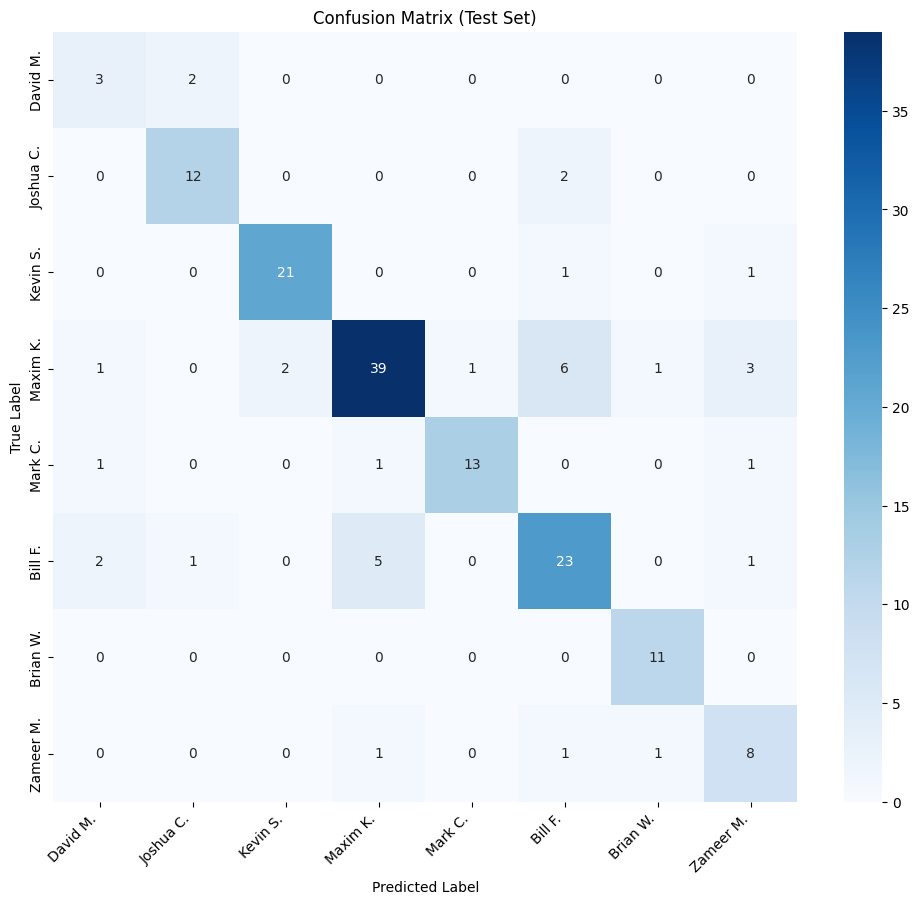

In [85]:
from sklearn.model_selection import train_test_split

# 1. Create Honest 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

# 2. Oversample ONLY Training Data (Prevent Leakage)
train_data = X_train.copy()
train_data['target'] = y_train
max_count = train_data['target'].value_counts().max()
balanced_chunks = []
for cls, group in train_data.groupby('target'):
    balanced_chunks.append(resample(group, replace=True, n_samples=max_count, random_state=42))
train_bal = pd.concat(balanced_chunks)
X_train_bal = train_bal.drop('target', axis=1)
y_train_bal = train_bal['target']

# 3. Train on 80% with Best Params
eval_model = XGBClassifier(**best_xgb_params, n_jobs=-1, random_state=42)
eval_pipe = Pipeline([('prep', prep), ('clf', eval_model)])
eval_pipe.fit(X_train_bal, y_train_bal)

# 4. Evaluate on 20% (Test Set)
y_probs_test = eval_pipe.predict_proba(X_test)
y_pred_test = eval_pipe.predict(X_test)

top1 = top_k_accuracy_score(y_test, y_probs_test, k=1)
top3 = top_k_accuracy_score(y_test, y_probs_test, k=3)

print(f'UNSEEN TEST SET METRICS (20% Split - {len(y_test)} Samples):')
print(f'Top-1 Accuracy: {top1:.2%} (Target: >60%)')
print(f'Top-3 Accuracy: {top3:.2%}')

print('\nClassification Report (Test Set):')
if 'le' in locals():
    target_names = [name_map.get(lbl, lbl) for lbl in le.classes_]
else:
    target_names = None
print(classification_report(y_test, y_pred_test, target_names=target_names))

# 5. Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.show()

# -----------------------------
### FINAL DEPLOYMENT TRAINING (Full Dataset)
# -----------------------------

In [86]:
# 1. Oversample FULL Data
full_data = X.copy()
full_data['target'] = y_enc
max_count = full_data['target'].value_counts().max()
balanced_chunks = []
for cls, group in full_data.groupby('target'):
    balanced_chunks.append(resample(group, replace=True, n_samples=max_count, random_state=42))
full_bal = pd.concat(balanced_chunks)
X_final = full_bal.drop('target', axis=1)
y_final = full_bal['target']

# 2. Train and Save Final Model
final_model = XGBClassifier(**best_xgb_params, n_jobs=-1, random_state=42)
final_pipe = Pipeline([('prep', prep), ('clf', final_model)])
final_pipe.fit(X_final, y_final)

print('Final Deployment Model Retrained on Full Dataset (824 Samples).')
joblib.dump(final_pipe, 'models/assignee_model_v7_robust.joblib')
joblib.dump(le, 'models/assignee_label_encoder_v7.joblib')

Final Deployment Model Retrained on Full Dataset (824 Samples).


['models/assignee_label_encoder_v7.joblib']